In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Raw data access

import os
os.chdir('/content/drive/MyDrive/MPXV_pycaret')

#### **Importing the modules** ####

In [3]:
from glob import glob
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [4]:
ls


 11.2_micro_marker.csv
 11_micro_marker.csv
 11_MPXV_Marker_Prediction_Using_Classification_Pycrate.ipynb
 13.2_clade_IIb_pROC.csv
 13.2_clade_IIb_pROC.gsheet
 13_clade_IIb_pROC.csv
 6_micro_marker.csv
 6_MPXV_Marker_Prediction_Using_Classification_Pycrate.ipynb
'Copy of 11_MPXV_Marker_Prediction_Using_Classification_Pycrate.ipynb'
'Copy of DenguePrediction_Using_Regression_Pycrate.ipynb'
 logs.log


#### **Load Dataset** ####

In [5]:
MPXV_df = pd.read_csv("11.2_micro_marker.csv", index_col=0)


In [6]:
display(MPXV_df.head(3))


,WDR37,NFAT5,ICAM5,ELL,PLAGL1,DHX38,GATA6,ZNF212,CBX6,ATP5MG,GM2A,group
GSM283173,-0.777775,-6.992444,-3.325945,-0.741301,-3.457608,-0.634338,-4.370812,-0.915753,0.028832,-0.316912,0.075901,0
GSM283177,-0.943354,-2.913841,-3.877194,0.780586,-3.040605,-2.089937,-3.657253,-2.267558,-0.233075,-0.777004,-0.518671,0
GSM283187,-1.333195,-3.734126,-3.888262,-0.289861,-3.960356,-2.548718,-4.700646,-2.237030,0.063841,-0.279897,-0.744807,0


#### **Data Preprocessing** ####
##### **Checking null entries** #####

In [7]:
MPXV_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, GSM283173 to GSM283405
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   WDR37   24 non-null     float64
 1   NFAT5   24 non-null     float64
 2   ICAM5   24 non-null     float64
 3   ELL     24 non-null     float64
 4   PLAGL1  24 non-null     float64
 5   DHX38   24 non-null     float64
 6   GATA6   24 non-null     float64
 7   ZNF212  24 non-null     float64
 8   CBX6    24 non-null     float64
 9   ATP5MG  24 non-null     float64
 10  GM2A    24 non-null     float64
 11  group   24 non-null     int64  
dtypes: float64(11), int64(1)
memory usage: 2.4+ KB


In [8]:
# Checking columns having null values
#MPXV_df.isna().sum()

In [9]:
# Getting the list of columns having missing values
#x = dengue_features.columns[dengue_features.isna().sum() > 0].tolist()
#x

In [10]:
# Filling the missing value with mean
#for i in x:
#    dengue_features[i] = dengue_features[i].fillna(dengue_features[i].mean())
#dengue_features.head()

##### **merge dataset** #####

In [11]:
# Adding total cases
#dengue_features['total_cases'] = dengue_labels['total_cases']
#dengue_features.head(3)

##### **Feature Engineering** #####
The dengue cases of San Juan sj and Iquitos iq are not dependent. So splitting them into different DataFrames

In [12]:
#X_sj = dengue_features[dengue_features['city'] == 'sj']
#X_iq = dengue_features[dengue_features['city'] == 'iq']

In [13]:
# MPXV_df = MPXV_df.drop(['condition'], axis=1)
#X_iq = X_iq.drop(['city', 'weekofyear', 'week_start_date'], axis=1)

In [14]:
# display(MPXV_df.head(2))
#display(X_iq.head(2))

In [15]:
#display(X_sj.head(2))
#display(X_iq.head(2))

##### **Changing the order of columns in X_sj and X_iq DataFrames** #####

In [16]:
# X_sj.columns

In [17]:
# X_sj_1 = X_sj.columns[-3:].values.tolist()
# X_sj_2 = X_sj.columns[:15].values.tolist()

In [18]:
# print(X_sj_1)

In [19]:
# years = X_sj_1 + X_sj_2
# print(years)

In [20]:
# X_sj = X_sj[years[::-1]].join(X_sj[X_sj.columns[:24]])
# X_sj.head(100)

In [21]:
# years = X_iq.columns[:23:-1].values.tolist()
# print(years)
# X_iq = X_iq[years[::-1]].join(X_iq[X_iq.columns[:24]])
# X_iq.head()

In [22]:
# Removing dummy variable trap
# X_sj = X_sj.drop(1990, axis=1)
# X_iq = X_iq.drop(2000, axis=1)

In [23]:
# x_sj_arr = X_sj.iloc[:].values
# x_iq_arr = X_iq.iloc[:].values

In [24]:
# y_sj = X_sj['total_cases'].values
# y_iq = X_iq['total_cases'].values

In [25]:
# X_sj = X_sj.drop('total_cases', axis=1).values
# X_iq = X_iq.drop('total_cases', axis=1).values

#### **Splitting the dataframes into train and test** ####

In [26]:
!pip install pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 37.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 81.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.0/165.0 kB 23.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 31.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 13.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 28.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 14.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 11.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 46.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB

In [27]:
# import pycaret classification and init setup
from pycaret.classification import *
setup(MPXV_df, target = 'group', train_size = 0.8, session_id = 123)
# setup(X_iq, target = 'total_cases', train_size = 0.8, session_id = 123)

,Description,Value
0,Session id,123
1,Target,group
2,Target type,Binary
3,Original data shape,"(24, 12)"
4,Transformed data shape,"(24, 12)"
5,Transformed train set shape,"(19, 12)"
6,Transformed test set shape,"(5, 12)"
7,Numeric features,11
8,Preprocess,True
9,Imputation type,simple


In [28]:
import pycaret
print(pycaret.__version__)


3.3.2


## **Compare Models** ##

In [29]:
# compare baseline models
best = compare_models()
print(best)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9500,0.6000,0.5000,0.5000,0.5000,nan,0.5000,0.5790
nb,Naive Bayes,0.9500,0.6000,0.5000,0.5000,0.5000,nan,0.5000,0.0310
svm,SVM - Linear Kernel,0.9500,0.6000,0.5000,0.5000,0.5000,nan,0.5000,0.0590
ridge,Ridge Classifier,0.9500,0.6000,0.5000,0.5000,0.5000,nan,0.5000,0.1030
rf,Random Forest Classifier,0.9500,0.6000,0.5000,0.5000,0.5000,nan,0.5000,0.5060
ada,Ada Boost Classifier,0.9500,0.5500,0.5000,0.5000,0.5000,nan,0.5000,0.0650
et,Extra Trees Classifier,0.9500,0.6000,0.5000,0.5000,0.5000,nan,0.5000,0.2580
knn,K Neighbors Classifier,0.9000,0.5500,0.4000,0.4000,0.4000,nan,0.4000,0.0440
dt,Decision Tree Classifier,0.9000,0.5500,0.5000,0.5000,0.5000,nan,0.5000,0.0650
lda,Linear Discriminant Analysis,0.9000,0.6000,0.5000,0.5000,0.5000,nan,0.5000,0.0480


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


## **Create Model**##

In [30]:
# create model
rf = create_model('rf')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
1,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
2,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,0.5000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [31]:
# print model parameters
print(rf)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=123, verbose=0,
                       warm_start=False)


## **Tune Model** ##

In [32]:
# tune hyperparameters of et
tuned_rf = tune_model(rf)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
1,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
2,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,0.5000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
6,0.5000,1.0000,1.0000,0.5000,0.6667,0.0000,0.0000
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [33]:
# print tuned model
print(tuned_rf)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=123, verbose=0,
                       warm_start=False)


In [34]:
tuned_rf

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=123, verbose=0,
                       warm_start=False)

In [35]:
# to access the tuner object you can set return_tuner = True
tuned_rf, tuner = tune_model(rf, return_tuner=True)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
1,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
2,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,0.5000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
6,0.5000,1.0000,1.0000,0.5000,0.6667,0.0000,0.0000
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [36]:
tuner

RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=None, shuffle=False),
                   error_score=nan,
                   estimator=Pipeline(memory=Memory(location=None),
                                      steps=[('numerical_imputer',
                                              TransformerWrapper(exclude=None,
                                                                 include=['WDR37',
                                                                          'NFAT5',
                                                                          'ICAM5',
                                                                          'ELL',
                                                                          'PLAGL1',
                                                                          'DHX38',
                                                                          'GATA6',
                                                                          'ZNF212',
                                                                          'CBX6',
                                                                          'ATP5MG',
                                                                          'GM2A'],
                                                                 transformer=SimpleImputer(add_indicator=False,...
                                        'actual_estimator__min_samples_leaf': [2,
                                                                               3,
                                                                               4,
                                                                               5,
                                                                               6],
                                        'actual_estimator__min_samples_split': [2,
                                                                                5,
                                                                                7,
                                                                                9,
                                                                                10],
                                        'actual_estimator__n_estimators': [10,
                                                                           20,
                                                                           30,
                                                                           40,
                                                                           50,
                                                                           60,
                                                                           70,
                                                                           80,
                                                                           90,
                                                                           100,
                                                                           110,
                                                                           120,
                                                                           130,
                                                                           140,
                                                                           150,
                                                                           160,
                                                                           170,
                                                                           180,
                                                                           190,
                                                                           200,
                                                                           210,
                                                                           220,
                                                         

## **Analyze Model** ##

In [37]:
#plot_model(rf, plot = 'residuals')

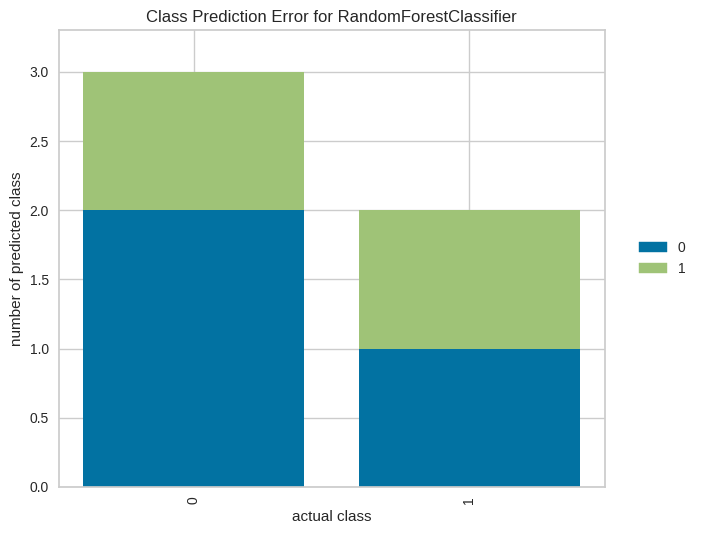

In [38]:
# predicting error plot
plot_model(rf, plot = 'error')

In [39]:
# cooks distance plot
#plot_model(rf, plot = 'cooks')

In [ ]:
# recursive feature elemination
plot_model(rf, plot = 'rfe')

In [ ]:
# learning curve
plot_model(rf, plot = 'learning')

In [ ]:
# validation curve
plot_model(rf, plot = 'vc')

In [ ]:
# manifold learning plot
plot_model(rf, plot = 'manifold')

In [ ]:
# plot feature importance
plot_model(rf, plot = 'feature')

## **Evaluate Model** ##

In [ ]:
# evaluate model
evaluate_model(rf)

## **Finalize Model** ##

In [ ]:
# finalize a model
finalize_model(rf)

## **Prediction** ##

In [ ]:
# predict on test set
holdout_pred = predict_model(rf)